In [278]:
#importing
import csv
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import keras
import pandas as pd
import xgboost as xgb
from scipy.stats import norm
from scipy.signal import chirp, find_peaks, peak_widths

In [279]:
XGBoost_data = np.loadtxt('XGBoost_distances_xgboost.csv')
MLP_data = np.loadtxt('MLP_distances.csv')

In [280]:
XGBoost_best = XGBoost_data.reshape((-1, 331, 331))[30]
MLP_best = MLP_data.reshape((-1, 331, 331))[30]

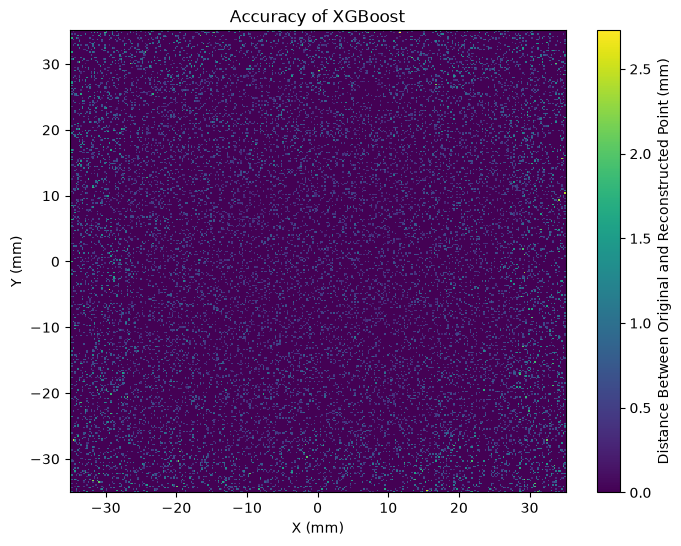

In [281]:
#XGBoost Color Map
xaxis = 1000*np.linspace(-0.035, 0.035, 331)
yaxis = 1000*np.linspace(-0.035, 0.035, 331)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xaxis,yaxis,XGBoost_best,shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of XGBoost')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/accuracy_xgb.png',dpi=300,bbox_inches='tight')
plt.show()


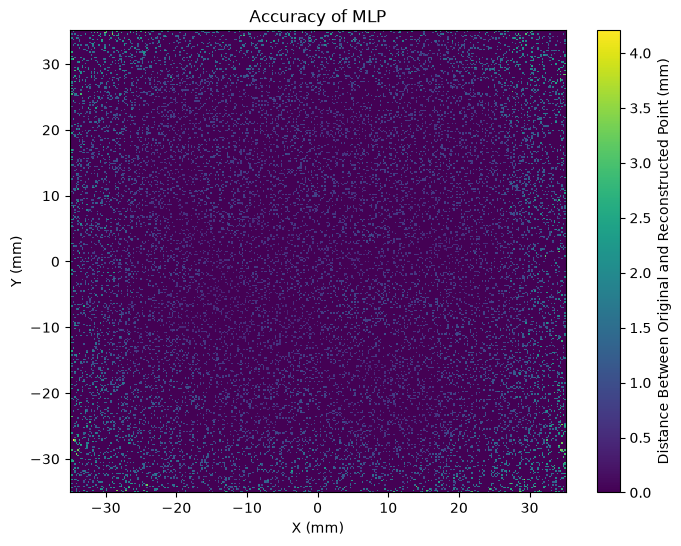

In [282]:
#MLP Color Map
xaxis = 1000*np.linspace(-0.035, 0.035, 331)
yaxis = 1000*np.linspace(-0.035, 0.035, 331)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xaxis,yaxis,MLP_best,shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of MLP')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/accuracy_mlp.png',dpi=300,bbox_inches='tight')
plt.show()

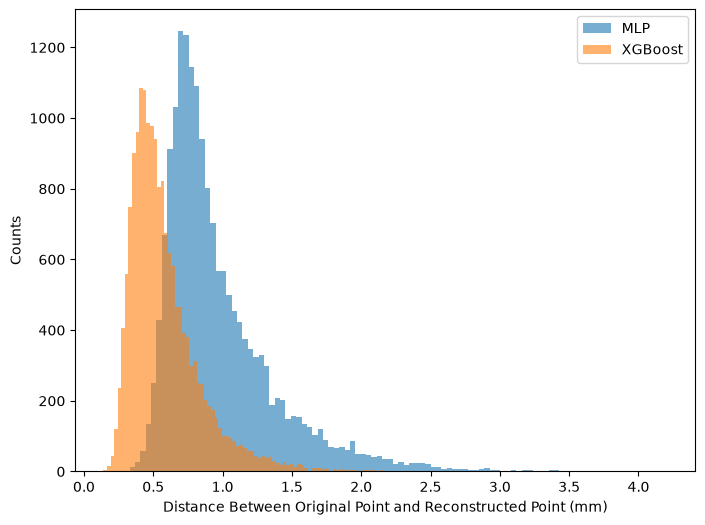

In [283]:
#Histogram comparing both methods
MLP_distances = MLP_best.ravel()
XGBoost_distances = XGBoost_best.ravel()
MLP_distances = MLP_distances[MLP_distances != 0]
XGBoost_distances = XGBoost_distances[XGBoost_distances != 0]

plt.figure(figsize=(8, 6))
plt.hist(MLP_distances,bins=100,alpha=0.6,label='MLP')
plt.hist(XGBoost_distances,bins=100,alpha=0.6,label='XGBoost')
plt.xlabel('Distance Between Original Point and Reconstructed Point (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper right')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/histogram_mlp_xgb.png',dpi=300,bbox_inches='tight')
plt.show()


In [284]:
#Averages
for i in range(35):
    print("Average XGBoost Distance (mm): " + str(np.average(XGBoost_data[i])))
    print("Average MLP Distance (mm): " + str(np.average(MLP_data[i])))

Average XGBoost Distance (mm): 0.13475539159585448
Average MLP Distance (mm): 0.2007478020195271
Average XGBoost Distance (mm): 0.13373712795027579
Average MLP Distance (mm): 0.1960515757650109
Average XGBoost Distance (mm): 0.538762658500762
Average MLP Distance (mm): 0.64520671450803
Average XGBoost Distance (mm): 0.132172172576091
Average MLP Distance (mm): 0.1982291855528169
Average XGBoost Distance (mm): 0.13205453036659784
Average MLP Distance (mm): 0.19789950766589626
Average XGBoost Distance (mm): 0.1330233710613216
Average MLP Distance (mm): 0.19040654425979092
Average XGBoost Distance (mm): 0.1330093525445131
Average MLP Distance (mm): 0.18728636933680237
Average XGBoost Distance (mm): 0.13285659193576488
Average MLP Distance (mm): 0.19045325003819547
Average XGBoost Distance (mm): 0.13378757687815132
Average MLP Distance (mm): 0.19557732473116596
Average XGBoost Distance (mm): 0.13256446958217472
Average MLP Distance (mm): 0.18329539313932858
Average XGBoost Distance (mm): 0

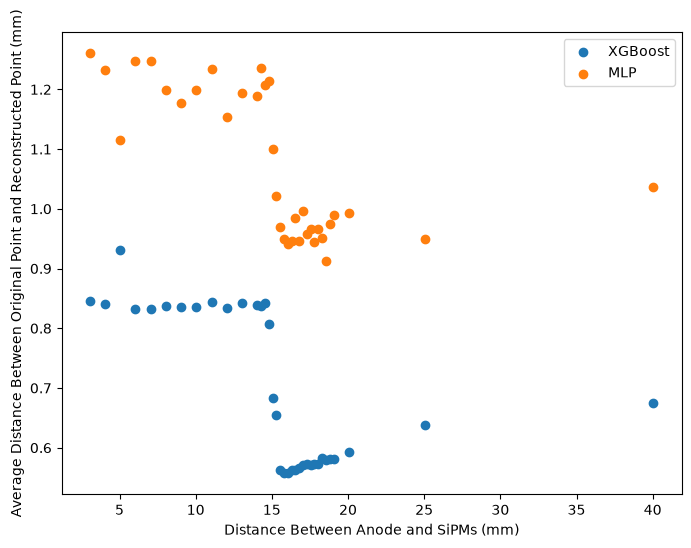

In [285]:
numbers = [3.05, 4.05, 5.05, 6.05, 7.05, 8.05, 9.05, 10.05, 11.05, 12.05, 13.05, 14.05, 14.3, 14.55, 14.8, 15.05, 15.3, 15.55, 15.8, 16.05, 16.3, 16.55, 16.8, 17.05, 17.3, 17.55, 17.8, 18.05, 18.3, 18.55, 18.8, 19.05, 20.05, 25.05, 40.05]

XGBoosty = []
MLPy = []

for i in range(len(numbers)):

    XGBoost_values = XGBoost_data[i]
    MLP_values = MLP_data[i]

    XGBoost_values = XGBoost_values[XGBoost_values != 0]
    MLP_values = MLP_values[MLP_values != 0]

    XGBoosty.append(np.average(XGBoost_values))
    MLPy.append(np.average(MLP_values))

plt.figure(figsize=(8, 6))

plt.scatter(numbers, XGBoosty, label='XGBoost')
plt.scatter(numbers, MLPy, label='MLP')

plt.xlabel('Distance Between Anode and SiPMs (mm)')
plt.ylabel('Average Distance Between Original Point and Reconstructed Point (mm)')

plt.legend(loc='upper right')

plt.savefig(
    '/Users/judyz/Desktop/PET-4x4/build/scatter.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

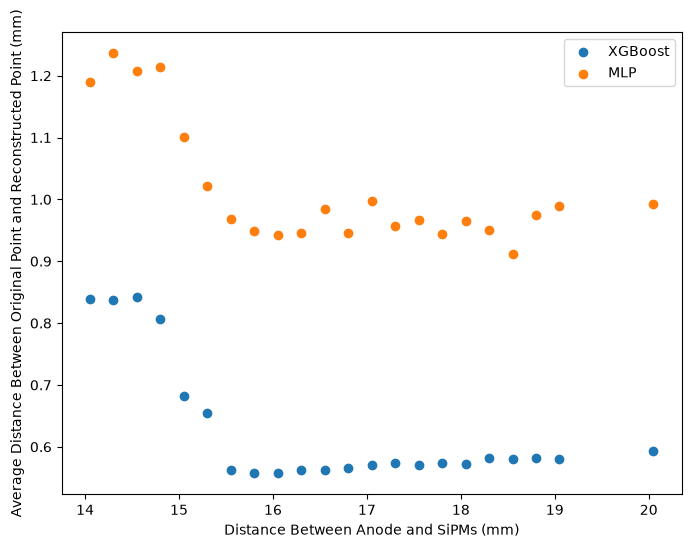

In [286]:
numbers = [14.05, 14.3, 14.55, 14.8, 15.05, 15.3, 15.55, 15.8, 16.05, 16.3, 16.55, 16.8, 17.05, 17.3, 17.55, 17.8, 18.05, 18.3, 18.55, 18.8, 19.05, 20.05]

XGBoosty = []
MLPy = []

start_index = 11

for i in range(len(numbers)):
    XGBoost_values = XGBoost_data[i + start_index]
    MLP_values = MLP_data[i + start_index]

    XGBoost_values = XGBoost_values[XGBoost_values != 0]
    MLP_values = MLP_values[MLP_values != 0]

    XGBoosty.append(np.average(XGBoost_values))
    MLPy.append(np.average(MLP_values))

plt.figure(figsize=(8, 6))

plt.scatter(numbers, XGBoosty, label='XGBoost')
plt.scatter(numbers, MLPy, label='MLP')

plt.xlabel('Distance Between Anode and SiPMs (mm)')
plt.ylabel('Average Distance Between Original Point and Reconstructed Point (mm)')

plt.legend(loc='upper right')

plt.savefig('/Users/judyz/Desktop/PET-4x4/build/scatter_cut.png',dpi=300,bbox_inches='tight')

plt.show()

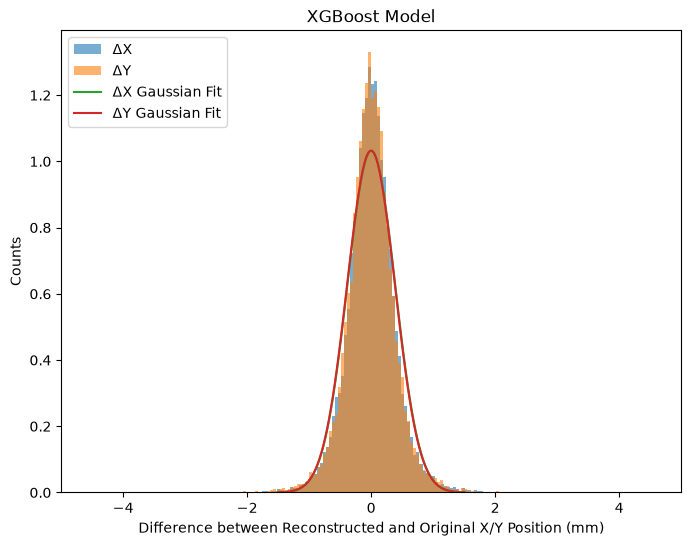

XGBoost FWHM:
[[0.90989725 0.90949768]]
XGBoost Means:
[[ 0.0021197  -0.00272869]]
RMSE X: 0.3863740744119317 mm
RMSE Y: 0.3862082310466748 mm
RMSE XY: 0.38629116162933286 mm


In [287]:
# XGBoost Delta

XGBoost_delta_data = np.loadtxt('XGBoost_distances_delta.csv')
XGBoost_delta_data = XGBoost_delta_data.reshape((35, 331, 331,2))

#[i] is the index
element = XGBoost_delta_data[30]
delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]
delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []
meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)
standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)

x_gaussian = np.linspace(-1.5, 1.5, 100)
xy = norm.pdf(x_gaussian,meanx,stdx)
yy = norm.pdf(x_gaussian,meany,stdy)

plt.plot(x_gaussian,xy,label='ΔX Gaussian Fit')
plt.plot(x_gaussian,yy,label='ΔY Gaussian Fit')
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('XGBoost Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/xgb.png',dpi=300,bbox_inches='tight')
plt.show()

print("XGBoost FWHM:")
print(np.array(standard_deviations) * 2.355)
print("XGBoost Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")

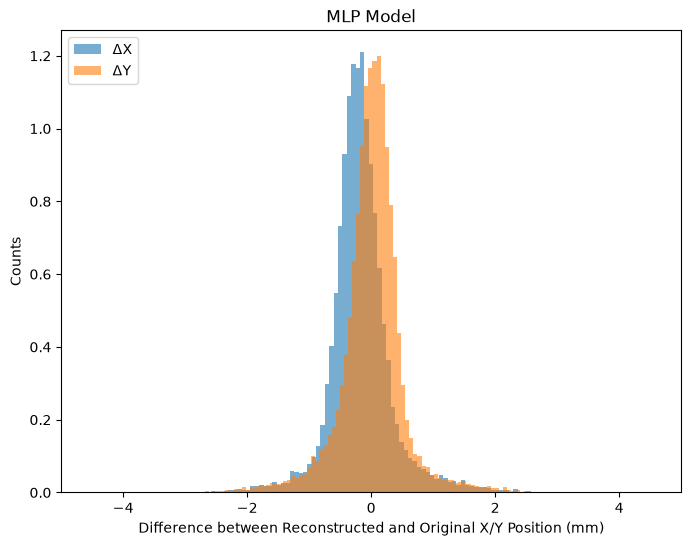

MLP Means:
[[-0.16857682  0.01579949]]
RMSE X: 0.538116618744997 mm
RMSE Y: 0.5189892264268152 mm
RMSE XY: 0.5286394388033552 mm


In [290]:
#MLP Delta
MLP_delta_data = np.loadtxt('MLP_distances_delta.csv')
MLP_delta_data = MLP_delta_data.reshape((35, 331, 331, 2))

element = MLP_delta_data[30]
delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]

delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []

meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)

standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('MLP Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/mlp.png',dpi=300,bbox_inches='tight')
plt.show()


# print("MLP FWHM:")
# print(np.array(standard_deviations) * 2.355)

print("MLP Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")



In [292]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout


# =========================
# 1. LOAD ORIGINAL CSV
# =========================

q = 14.8

file_path = f'/Users/judyz/Desktop/PET-4x4/build/14.05mm/14.05mm.csv'

df = pd.read_csv(file_path)

# 16 SiPM signals
X = df.iloc[:, 1:17].values

# Original x,y position
y = df.iloc[:, 17:19].values

print("X shape:", X.shape)
print("y shape:", y.shape)


# =========================
# 2. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# =========================
# 3. STANDARDIZE
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# 4. SAME MLP ARCHITECTURE
# =========================

model = Sequential()

model.add(Dense(128, input_dim=16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(2, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


# =========================
# 5. TRAIN
# =========================

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)


# =========================
# 6. PREDICT TEST SET ONLY
# =========================

y_test_pred = model.predict(X_test, verbose=0)


# =========================
# 7. TEST RMSE
# =========================

test_delta_x = y_test_pred[:, 0] - y_test[:, 0]
test_delta_y = y_test_pred[:, 1] - y_test[:, 1]

test_rmse_x = np.sqrt(np.mean(test_delta_x**2))
test_rmse_y = np.sqrt(np.mean(test_delta_y**2))

test_rmse_xy = np.sqrt(
    np.mean((test_delta_x**2 + test_delta_y**2) / 2)
)

print("\nTEST RMSE")
print("RMSE X:", test_rmse_x, "mm")
print("RMSE Y:", test_rmse_y, "mm")
print("RMSE XY:", test_rmse_xy, "mm")

X shape: (20000, 16)
y shape: (20000, 2)


/Users/judyz/Desktop/PET-4x4/venv312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



TEST RMSE
RMSE X: 1.1852796455248273 mm
RMSE Y: 1.5077574647587924 mm
RMSE XY: 1.3561379742915767 mm


In [293]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout


# =========================
# 1. LOAD ORIGINAL CSV
# =========================

q = 14.8

file_path = f'/Users/judyz/Desktop/PET-4x4/build/15.05mm/15.05mm.csv'

df = pd.read_csv(file_path)

# 16 SiPM signals
X = df.iloc[:, 1:17].values

# Original x,y position
y = df.iloc[:, 17:19].values

print("X shape:", X.shape)
print("y shape:", y.shape)


# =========================
# 2. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# =========================
# 3. STANDARDIZE
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# 4. SAME MLP ARCHITECTURE
# =========================

model = Sequential()

model.add(Dense(128, input_dim=16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(2, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


# =========================
# 5. TRAIN
# =========================

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)


# =========================
# 6. PREDICT TEST SET ONLY
# =========================

y_test_pred = model.predict(X_test, verbose=0)


# =========================
# 7. TEST RMSE
# =========================

test_delta_x = y_test_pred[:, 0] - y_test[:, 0]
test_delta_y = y_test_pred[:, 1] - y_test[:, 1]

test_rmse_x = np.sqrt(np.mean(test_delta_x**2))
test_rmse_y = np.sqrt(np.mean(test_delta_y**2))

test_rmse_xy = np.sqrt(
    np.mean((test_delta_x**2 + test_delta_y**2) / 2)
)

print("\nTEST RMSE")
print("RMSE X:", test_rmse_x, "mm")
print("RMSE Y:", test_rmse_y, "mm")
print("RMSE XY:", test_rmse_xy, "mm")

X shape: (20000, 16)
y shape: (20000, 2)


/Users/judyz/Desktop/PET-4x4/venv312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



TEST RMSE
RMSE X: 1.1429497033136036 mm
RMSE Y: 1.1215057457028614 mm
RMSE XY: 1.1322784909087484 mm


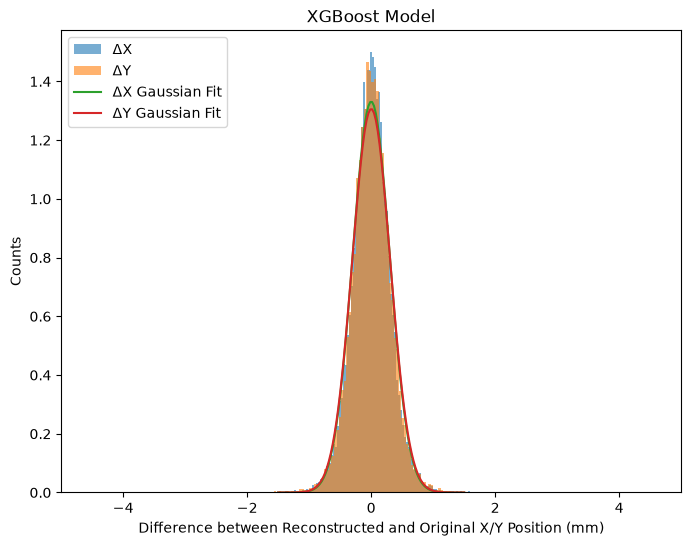

XGBoost cut FWHM:
[[0.70560547 0.71914549]]
XGBoost cut Means:
[[0.00070339 0.00104142]]
RMSE X: 0.2996209818395034 mm
RMSE Y: 0.30537140977852056 mm
RMSE XY: 0.3025098598959951 mm


In [ ]:
# XGBoost Cut 
XGBoost_data_cut = np.loadtxt('XGBoost_distances_delta_cut.csv')
XGBoost_data_cut = XGBoost_data_cut.reshape((35, 301, 301, 2))
element = XGBoost_data_cut[30]

delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]
delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []

meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)

standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)

x_gaussian = np.linspace(-1.5, 1.5, 100)
xy = norm.pdf(x_gaussian,meanx,stdx)
yy = norm.pdf(x_gaussian,meany,stdy)

plt.plot(x_gaussian,xy,label='ΔX Gaussian Fit')
plt.plot(x_gaussian,yy,label='ΔY Gaussian Fit')
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('XGBoost Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/xgb_cut.png',dpi=300,bbox_inches='tight')
plt.show()

print("XGBoost cut FWHM:")
print(np.array(standard_deviations) * 2.355)

print("XGBoost cut Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")

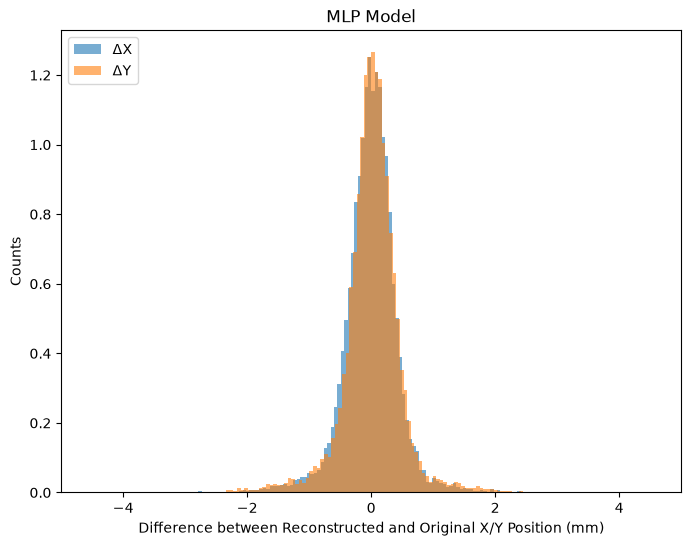

MLP cut Means:
[[-0.00821699  0.01491734]]
RMSE X: 0.4302435960553974 mm
RMSE Y: 0.46995602063901815 mm
RMSE XY: 0.45053757517078485 mm


In [ ]:
#MLP Cut Delta
MLP_data_cut = np.loadtxt('MLP_distances_delta_cut.csv')
MLP_data_cut = MLP_data_cut.reshape((35, 301, 301, 2))

element = MLP_data_cut[30]

delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]

delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []

meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)

standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('MLP Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/mlp_cut.png',dpi=300,bbox_inches='tight')
plt.show()

# print("MLP cut FWHM:")
# print(np.array(standard_deviations) * 2.355)

print("MLP cut Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")


In [ ]:
MLP_data_cut_distances = np.zeros((35, 301, 301))
for a in range(35):
    for b in range(301):
        for c in range(301):
            MLP_data_cut_distances[a][b][c] = math.dist(MLP_data_cut[a][b][c],[0, 0])

for array in MLP_data_cut_distances:
    print(np.average(array))

0.10035295395584141
0.09744093998853562
0.38214460841695946
0.08981025824568196
0.09159620987167247
0.09599676076391314
0.10435038264796945
0.10055782056143016
0.09269097041518799
0.09216279532178095
0.09698606667010108
0.09406157212292887
0.09726906008275507
0.09590416747857287
0.09489768243185764
0.08685981292524213
0.09226434087884698
0.09256850457187797
0.09434238085620388
0.081629541326755
0.0845591904457658
0.07541164452005969
0.08731397010996683
0.07618560200926482
0.09101714545397455
0.0895423010257486
0.08787007661208596
0.08858165856183425
0.09145163311167284
0.09432549421563899
0.07967822930345493
0.08346077987664664
0.08297966120785673
0.09091324484125689
0.09880078573258556


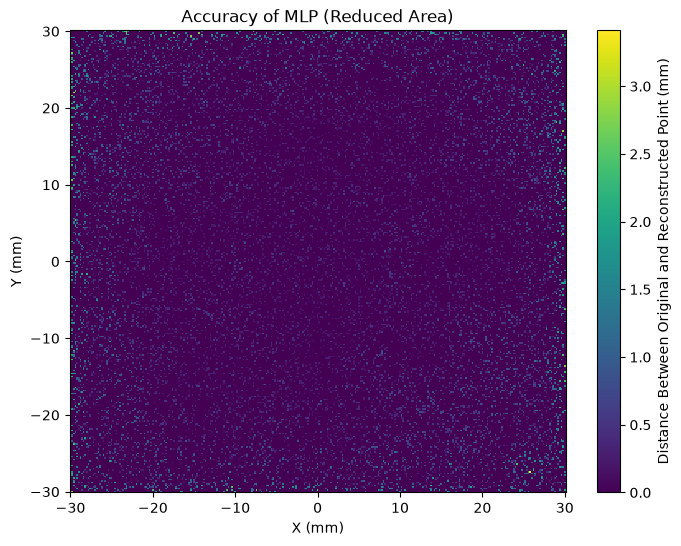

In [ ]:
#MLP Cut Accuracy Plot
xaxis_cut = 1000*np.linspace(-0.0300,0.0300,301)
yaxis_cut = 1000*np.linspace(-0.0300,0.0300,301)
MLP_data_cut_distances = np.sqrt(MLP_data_cut[:, :, :, 0]**2 +MLP_data_cut[:, :, :, 1]**2)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xaxis_cut,yaxis_cut,MLP_data_cut_distances[30],shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of MLP (Reduced Area)')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/accuracy_mlp_cut',dpi=300,bbox_inches='tight')
plt.show()




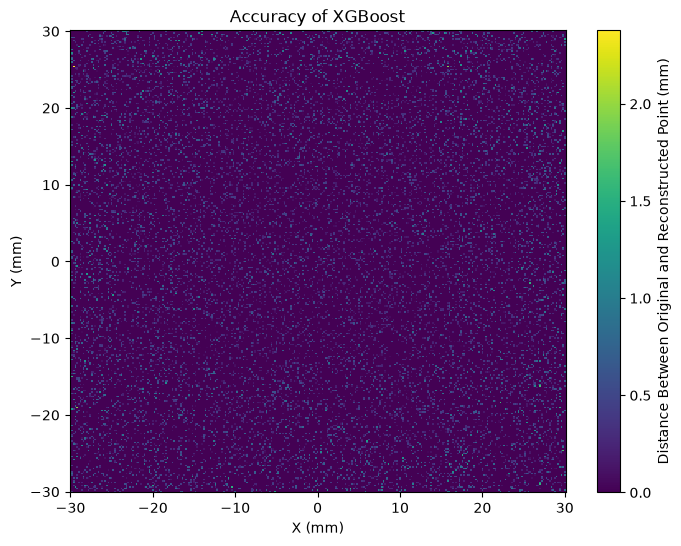

In [ ]:
#XGBoost Cut Accuracy Plot
plt.figure(figsize=(8, 6))
XGBoost_data_cut_distances = np.sqrt(XGBoost_data_cut[:, :, :, 0]**2 +XGBoost_data_cut[:, :, :, 1]**2)
plt.pcolormesh(xaxis_cut,yaxis_cut,XGBoost_data_cut_distances[30],shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of XGBoost')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/18.8mm/accuracy_xgb_cut.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
##TEST RMSE; not included in results section, just experimen####3
import numpy as np
import pandas as pd
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout


distances = [14.05, 14.30, 14.55, 14.80, 15.05, 15.30, 15.55, 15.80, 16.05, 17.05, 18.05, 19.05]

sipm_coordinates = [
    [-24.375, -24.375],
    [-24.375,  -8.125],
    [-24.375,   8.125],
    [-24.375,  24.375],
    [ -8.125, -24.375],
    [ -8.125,  -8.125],
    [ -8.125,   8.125],
    [ -8.125,  24.375],
    [  8.125, -24.375],
    [  8.125,  -8.125],
    [  8.125,   8.125],
    [  8.125,  24.375],
    [ 24.375, -24.375],
    [ 24.375,  -8.125],
    [ 24.375,   8.125],
    [ 24.375,  24.375]
]

results = []

for q in distances:

    print("\n===================================")
    print("DISTANCE:", q, "mm")
    print("===================================")

    file_path = f'/Users/judyz/Desktop/PET-4x4/build/{q}mm/{q}mm.csv'

    df = pd.read_csv(file_path)

    X = df.iloc[:, 1:17].values
    y = df.iloc[:, 17:19].values

    print("Events:", len(X))

    regular_delta_x = []
    regular_delta_y = []

    for i in range(len(X)):

        maximum_value = np.argmax(X[i])
        reconstructed_position = np.array(sipm_coordinates[maximum_value])
        error = reconstructed_position - y[i]
        regular_delta_x.append(error[0])
        regular_delta_y.append(error[1])

    regular_delta_x = np.array(regular_delta_x)
    regular_delta_y = np.array(regular_delta_y)

    regular_rmse_xy = np.sqrt(np.mean((regular_delta_x**2 + regular_delta_y**2)/2))

    weighted_delta_x = []
    weighted_delta_y = []

    for i in range(len(X)):

        total_signal = np.sum(X[i])

        if total_signal == 0:
            continue

        coord_x = sum(
            X[i][j] * sipm_coordinates[j][0]
            for j in range(16)
        ) / total_signal

        coord_y = sum(
            X[i][j] * sipm_coordinates[j][1]
            for j in range(16)
        ) / total_signal

        error = np.array([coord_x, coord_y]) - y[i]

        weighted_delta_x.append(error[0])
        weighted_delta_y.append(error[1])

    weighted_delta_x = np.array(weighted_delta_x)
    weighted_delta_y = np.array(weighted_delta_y)

    weighted_rmse_xy = np.sqrt(np.mean((weighted_delta_x**2 + weighted_delta_y**2) / 2))

    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Same architecture as MLP
    model = Sequential()

    model.add(Dense(128, input_dim=16, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(2, activation='linear'))

    model.compile(optimizer='adam',loss='mean_squared_error')

    model.fit(X_train,y_train,epochs=100,batch_size=32,verbose=0)
    y_test_pred = model.predict(X_test,verbose=0)
    test_delta_x = y_test_pred[:, 0] - y_test[:, 0]
    test_delta_y = y_test_pred[:, 1] - y_test[:, 1]
    mlp_rmse_xy = np.sqrt(np.mean((test_delta_x**2 + test_delta_y**2) / 2))

    results.append([
        q,
        regular_rmse_xy,
        weighted_rmse_xy,
        mlp_rmse_xy
    ])

    print("Regular RMSE XY: ", regular_rmse_xy, "mm")
    print("Weighted RMSE XY:", weighted_rmse_xy, "mm")
    print("MLP Test RMSE XY:", mlp_rmse_xy, "mm")

results_df = pd.DataFrame(
    results,
    columns=[
        "Distance (mm)",
        "Regular RMSE (mm)",
        "Weighted RMSE (mm)",
        "MLP Test RMSE (mm)"
    ]
)

print("\n\nFINAL RESULTS")
print(results_df.to_string(index=False))


DISTANCE: 14.05 mm
Events: 20000


/Users/judyz/Desktop/PET-4x4/venv312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regular RMSE XY:  4.984707310560258 mm
Weighted RMSE XY: 16.10892632151147 mm
MLP Test RMSE XY: 1.336366102447406 mm

DISTANCE: 14.3 mm
Events: 20000


/Users/judyz/Desktop/PET-4x4/venv312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regular RMSE XY:  4.987090799042097 mm
Weighted RMSE XY: 16.121591687633437 mm
MLP Test RMSE XY: 1.212306233138804 mm

DISTANCE: 14.55 mm
Events: 20000


...

Regular RMSE XY:  5.016297760070571 mm
Weighted RMSE XY: 15.286325805669254 mm
MLP Test RMSE XY: 0.779845734400707 mm

DISTANCE: 18.05 mm
Events: 20000


/Users/judyz/Desktop/PET-4x4/venv312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regular RMSE XY:  5.017689065863594 mm
Weighted RMSE XY: 15.355178451805788 mm
MLP Test RMSE XY: 0.8570236732988205 mm

DISTANCE: 19.05 mm
Events: 20000


/Users/judyz/Desktop/PET-4x4/venv312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Regular RMSE XY:  5.023361975491046 mm
Weighted RMSE XY: 15.38520435775869 mm
MLP Test RMSE XY: 0.779395212173356 mm


FINAL RESULTS
 Distance (mm)  Regular RMSE (mm)  Weighted RMSE (mm)  MLP Test RMSE (mm)
         14.05           4.984707           16.108926            1.336366
         14.30           4.987091           16.121592            1.212306
         14.55           4.990764           16.084295            1.169918
         14.80           4.994118           15.828488            1.168078
         15.05           4.990390           15.377712            1.024713
         15.30           5.026902           15.318847            1.002406
         15.55           5.042946           15.239049            0.824543
         15.80           5.011170           15.242206            0.757883
         16.05           5.023411           15.212114            0.798940
         17.05           5.016298           15.286326            0.779846
         18.05           5.017689           15.355178